In [7]:
# %reload_ext autoreload
# %autoreload 2

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller
import matplotlib.pyplot as plt
import numpy as np
#Seed 1 ok :)
#Seed 67 ok :) with last comit workin seed 1

#Prmts:
#Width threshold for obstacle detection 
#Vision threshold to only keep center vision 



# exam seed 1, 67, 777
sim = MiniprojectSimulation(level=2, seed=69)
controller = Controller(sim)
banana_xy= np.array(sim.world.banana_xy)
min_dist=np.inf

for _ in trange(60000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()
    
print(f"min dist", min_dist)   
controller.close()
sim.renderer.show_in_notebook()

 17%|█▋        | 9995/60000 [00:26<01:25, 584.99it/s]

Fin Stuck Mode au step 9998. Et c'est reparti pour un touuuur


 34%|███▍      | 20693/60000 [00:57<01:53, 346.23it/s]

Fin Stuck Mode au step 20581. Et c'est reparti pour un touuuur


 51%|█████     | 30644/60000 [01:30<01:57, 249.24it/s]

...

Fin Stuck Mode au step 50578. Et c'est reparti pour un touuuur


100%|██████████| 60000/60000 [03:13<00:00, 310.40it/s]


min dist inf
Saved video: raw_vision


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


In [ ]:
#controller.plot_head_trajectory(sim)


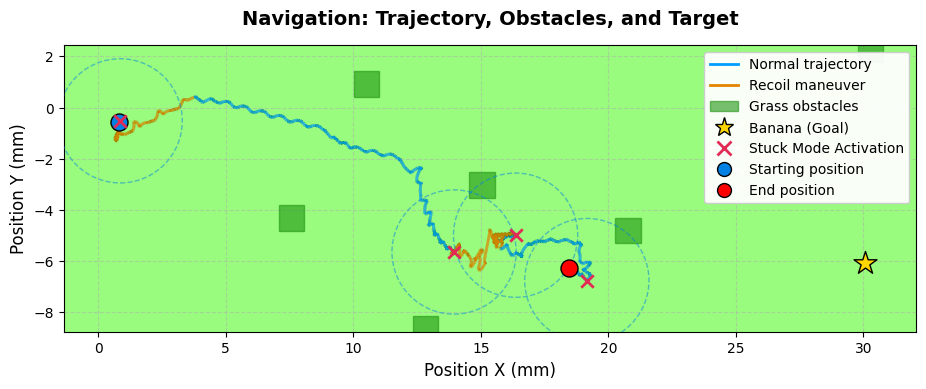

In [6]:
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import mujoco

head_positions, stuck_positions, maneuver_segments, end_stuck_positions = controller.get_trajectory_data()

if len(head_positions) == 0:
    print("La simulation n'a enregistré aucune position.")
else:
    x_coords = head_positions[:, 0]
    y_coords = head_positions[:, 1]

    # 2. Initialisation de la figure
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_facecolor("#99fc7e") 

    geom_xpos = sim.mj_data.geom_xpos
    banana_pos = None
    
    for i in range(sim.mj_model.ngeom):
        geom_name = mujoco.mj_id2name(sim.mj_model, mujoco.mjtObj.mjOBJ_GEOM, i) or ""
        
        is_fly_part = any(x in geom_name.lower() for x in ["fly", "tarsus", "femur", "tibia", "body"])
        is_floor = "floor" in geom_name.lower() or "ground" in geom_name.lower()

        if "peel" in geom_name.lower():
            banana_pos = geom_xpos[i]
            continue # On passe à la suite pour ne pas la traiter comme obstacle

        if len(geom_name) == len("2cd9ededa3954e0991d15a3127b45810"):
            pos = geom_xpos[i]
            size = sim.mj_model.geom_size[i]
            if size[0] < 0.01: continue

            rect = patches.Rectangle((pos[0] - size[0], pos[1] - size[1]), size[0]*2, size[1]*2, 
                                    color="#1f9512", alpha=0.6, zorder=2)
            ax.add_patch(rect)

    # 4. TRACÉ DE LA TRAJECTOIRE
    points = np.array([x_coords, y_coords]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    segment_colors = np.array(['#009dff'] * (len(x_coords) - 1))

    for start, end in maneuver_segments:
        # On s'assure de ne pas dépasser les bornes du tableau
        start_idx = max(0, start)
        end_idx = min(len(segment_colors), end)
        segment_colors[start_idx:end_idx] = '#e28400'

    lc = LineCollection(segments, colors=segment_colors, linewidth=2, zorder=3)
    ax.add_collection(lc)

    ax.scatter(x_coords[0], y_coords[0], color="#0081e3", edgecolor="black", s=150, zorder=3)
    ax.scatter(x_coords[-1], y_coords[-1], color="#ff0000", edgecolor="black", s=150, zorder=8)

    if banana_pos is not None:
        # Utilise un marqueur texte personnalisé
         ax.scatter(banana_pos[0], banana_pos[1], color="gold", edgecolor="black", s=300, marker="*", zorder=7) 
        
    # 5. AJOUT DES CROIX POUR LE "STUCK MODE"
    if len(stuck_positions) > 0:
        ax.scatter(stuck_positions[:, 0], stuck_positions[:, 1], color="#e12a54", marker="x", s=80, linewidths=2, zorder=6)
        # cercle pontillé plus large pour mieux visualiser les zones de "stuck mode"
        ax.scatter(stuck_positions[:, 0], stuck_positions[:, 1], facecolors='none', edgecolors='#0081e3', marker='o', s=8000, linewidths=1, linestyle='--', alpha=0.5, zorder=4)    
    
    # if len(end_stuck_positions) > 0:
    #     ax.scatter(end_stuck_positions[:, 0], end_stuck_positions[:, 1], color="#ffe100", marker="x", s=80, linewidths=2, zorder=6)
        # cercle pontillé plus large pour mieux visualiser les zones de "stuck mode"  
    
    # ==============================================================
    # CRÉATION DE LA LÉGENDE PERSONNALISÉE (Règle le problème du carré et des couleurs)
    # ==============================================================
    legend_elements = [
        # Ligne bleue pour l'avance normale
        Line2D([0], [0], color='#009dff', lw=2, label='Normal trajectory'),
        # Ligne orange pour la manoeuvre de recul
        Line2D([0], [0], color='#e28400', lw=2, label='Recoil maneuver'),
        # Carré vert pour les obstacles / herbes
        patches.Patch(color='#1f9512', alpha=0.6, label='Grass obstacles'),
        # L'étoile pour la banane
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markeredgecolor='black', markersize=14, label='Banana (Goal)'),
        # La croix pour le mode coincé
        Line2D([0], [0], marker='x', color='w', markeredgecolor='#e12a54', markersize=10, markeredgewidth=2, label='Stuck Mode Activation'),
        # Points de départ et fin
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#0081e3', markeredgecolor='black', markersize=10, label='Starting position'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff0000', markeredgecolor='black', markersize=10, label='End position')
    ]

    # 6. MISE EN FORME DU GRAPHIQUE
    ax.set_title("Navigation: Trajectory, Obstacles, and Target", fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel("Position X (mm)", fontsize=12)
    ax.set_ylabel("Position Y (mm)", fontsize=12)
    
    ax.grid(True, linestyle="--", alpha=0.5, zorder=1)
    ax.legend(handles=legend_elements, loc="upper right", framealpha=0.95, facecolor='white')
    
    ax.set_aspect('equal')

    padding = 2.0
    ax.set_xlim(min(x_coords.min(), banana_pos[0] if banana_pos is not None else 0) - padding, 
                max(x_coords.max(), banana_pos[0] if banana_pos is not None else 0) + padding)
    ax.set_ylim(min(y_coords.min(), banana_pos[1] if banana_pos is not None else 0) - padding, 
                max(y_coords.max(), banana_pos[1] if banana_pos is not None else 0) + padding)
    
    # Sauvegarde automatique en haute résolution pour le rapport PDF
    plt.savefig("rapport_trajectoire_obstacles.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
print(sim.world.banana_xy)

In [ ]:
import numpy as np
import tqdm
from flygym.compose import ActuatorType
from miniproject import MiniprojectSimulation
from submission.controller import Controller

MAX_NUM_STEPS = 70000
NUM_SEEDS = 10
LEVEL = 2  # change as needed
SUCCESS_RADIUS = 3.0

def run_single_seed(seed):
    sim = MiniprojectSimulation(level=LEVEL, seed=seed, back_cam=False, top_cam=False)
    controller = Controller(sim)

    def get_distance():
        fly_xy = np.array(sim.get_body_positions(sim.fly.name)[0][:2])
        banana_xy = np.array(sim.world.banana_xy)
        #print("banana",banana_xy)
        return np.linalg.norm(fly_xy - banana_xy)

    for step in range(MAX_NUM_STEPS):
        dist = get_distance()
        if dist <= SUCCESS_RADIUS:
            print(f"  seed={seed} → reached banana in {step} steps (dist={dist:.2f})")
            return dist

        joint_angles, adhesion_signals = controller.step(sim)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion_signals)
        sim.step()

    final_dist = get_distance()
    print(f"  seed={seed} → timed out (final dist={final_dist:.2f})")
    return final_dist


distances = []
seeds = np.random.randint(0, 1000, size=NUM_SEEDS)
#seeds=[1]
for seed in tqdm.tqdm(seeds):
    print(f"Seed {seed}")
    d = run_single_seed(int(seed))
    distances.append(d)
# d=run_single_seed(1)
# distances.append(d)

distances = np.array(distances)
print(f"\n--- Results over {NUM_SEEDS} seeds ---")
print(f"  Mean final distance : {distances.mean():.2f}")
print(f"  Std                 : {distances.std():.2f}")
print(f"  Min / Max           : {distances.min():.2f} / {distances.max():.2f}")
print(f"  Success rate (≤{SUCCESS_RADIUS}mm): {(distances <= SUCCESS_RADIUS).mean()*100:.0f}%")

  0%|          | 0/10 [00:00<?, ?it/s]

Seed 612


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'


Fin Stuck Mode au step 47470. Et c'est reparti pour un touuuur
Fin Stuck Mode au step 66794. Et c'est reparti pour un touuuur


 10%|█         | 1/10 [01:56<17:30, 116.67s/it]

...

Fin Stuck Mode au step 69442. Et c'est reparti pour un touuuur


 90%|█████████ | 9/10 [16:45<01:52, 112.85s/it]

  seed=738 → timed out (final dist=11.09)
Seed 288


OpenCV: FFMPEG: tag 0x39305056/'VP09' is not supported with codec id 167 and format 'webm / WebM'
100%|██████████| 10/10 [18:41<00:00, 112.14s/it]

  seed=288 → timed out (final dist=3.38)

--- Results over 10 seeds ---
  Mean final distance : 8.34
  Std                 : 5.35
  Min / Max           : 3.00 / 14.97
  Success rate (≤3.0mm): 40%


In [ ]:
controller.plot_head_trajectory(sim)
